# Plotting Lofar, Solar Orbiter, PSP, STEREO, Wind radio spectra together within SciQLop

/!\ You need to run this notebook from SciQLop's JupyterLab

In [6]:
from astropy.io import fits
import numpy as np
import json
from typing import Annotated
from matplotlib.dates import num2date

import speasy as spz
from speasy.products import SpeasyVariable, DataContainer, VariableAxis, VariableTimeAxis
from speasy.core.cache import CacheCall
from pycdfpp import to_datetime64

from SciQLop.user_api import TimeRange
from SciQLop.user_api.knobs import Knob, ChoiceKnob
from SciQLop.user_api.plot import create_plot_panel

Fisrt we need an index of all the Fits files so we can lookup which files cover a given time interval

In [7]:
import json
from functools import lru_cache
from pathlib import Path
import requests
from tempfile import TemporaryFile
import zipfile

import numpy as np

index_file = Path("./index.json")

if not index_file.exists():
    with TemporaryFile() as tmp:
        print("Downloading index...")
        tmp.write(requests.get("https://hephaistos.lpp.polytechnique.fr/data/jeandet/lofar_index.zip").content)
        tmp.flush()
        tmp.seek(0)
        z=zipfile.ZipFile(tmp)
        print("Extracting index...")
        z.extractall("./")
            

class Entry:
    def __init__(self, json_url, time_range, source, filename):
        self.url = json_url
        self.time_range = TimeRange(*time_range)
        self.source = source
        self.filename = filename 
    def __repr__(self):
        return f"""
{self.url}
{self.time_range}
{self.source}
{self.filename}
        """

@lru_cache()
def _index(beam, sap) -> list[Entry]:
    return sorted(
        [
            Entry(r['url'], r.get("time_range"), r.get("source"), r["filename"])
            for r in json.loads(index_file.read_text())
            if (beam in r["source"]) and (sap in r["source"])
        ], 
        key=lambda e:e.time_range.start())

def _entries_in_range(start, stop, beam="B000", sap="SAP000") -> list[Entry]:
    target_range = TimeRange(start, stop)
    return [r for r in _index(beam, sap) if target_range.intersects(r.time_range)]
    
def fits_urls_in_range(start, stop, beam="B000", sap="SAP000") -> list[str]:
    entries = _entries_in_range(start, stop, beam=beam, sap=sap)
    return [
        f"{e.url.rsplit('/json_files/', 1)[0]}/dynamic_spectra/{e.filename[:-5]}.fits"
        for e in entries
    ]
      


In [8]:
def lofar_time(t_arr) -> np.ndarray:
    t_arr = np.asarray(t_arr, dtype=np.float64)
    base = np.datetime64("1970-01-01") if t_arr[0] < 1e5 else np.datetime64("0000-12-31")
    days = np.floor(t_arr).astype(np.int64)
    ns = np.round((t_arr - days) * 86400e9).astype(np.int64)
    return base + days.astype("timedelta64[D]") + ns.astype("timedelta64[ns]")


@CacheCall(is_pure=True)
def _read_lofar(url: str)->SpeasyVariable or None:
    try:
        with fits.open(spz.core.any_files.any_loc_open(url, cache_remote_files=True)) as r:
            values = r[0].data.astype(np.float32)
            meta = dict(r[0].header)
            axes = r[1].data
            freq = np.asarray(axes["FREQ"][0]).astype(np.float32)
            time = lofar_time(axes["TIME"][0])
            freq = np.tile(freq, (len(time),1))
            # just ignore files where the frequency resolution is lower 
            # merging 
            if freq.shape[1] != 800:
                return None
        return SpeasyVariable(
            axes=[
                VariableTimeAxis(
                    time,
                    meta={
                        'FIELDNAM': 'Time',
                    }
                ), 
                VariableAxis(
                    freq*1e6,
                    meta={
                        'FIELDNAM': 'Frequency',
                        'UNITS': 'Hz', 
                    },
                    is_time_dependent=True
                )
            ], 
            values=DataContainer(values, meta=meta)
        )
    except Exception as e:
        print(e)
        return None




# Register Lofar as a new data product within SciQLop

In [9]:
%%vp --path "lofar" --start "2024-05-14T16:40:00" --stop "2024-05-14T17:40:00"

def lofar(start:float, stop:float, 
          beam: Annotated[int, Knob(min=0, max=216, step=1,label="Beam")] = 0, 
          sap:  Annotated[int, Knob(min=0, max=1, step=1,label="Sap")] = 0) -> Spectrogram["Lofar"]:
    values = list(map(_read_lofar, fits_urls_in_range(start, stop, beam=f"B{beam:03}", sap=f"SAP00{sap}")))
    try:
        return spz.products.variable.merge(values)
    except Exception as e:
        print(e)

Out[9]: 
(<function __main__.lofar(start: float, stop: float, beam: Annotated[int, Knob(min=0, max=216, step=1, label='Beam', unit='', description='', apply='live', choices=None, pattern='', widget='', color='')] = 0, sap: Annotated[int, Knob(min=0, max=1, step=1, label='Sap', unit='', description='', apply='live', choices=None, pattern='', widget='', color='')] = 0) -> <SciQLop.user_api.data_types._DataTypeWithLabels object at 0x7f2d46e49e50>>,
 Namespace(path='lofar', debug=False, start='2024-05-14T16:40:00', stop='2024-05-14T17:40:00'),
 VPTypeInfo(product_type='spectrogram', labels=['Lofar']))


(<function __main__.lofar(start: float, stop: float, beam: Annotated[int, Knob(min=0, max=216, step=1, label='Beam', unit='', description='', apply='live', choices=None, pattern='', widget='', color='')] = 0, sap: Annotated[int, Knob(min=0, max=1, step=1, label='Sap', unit='', description='', apply='live', choices=None, pattern='', widget='', color='')] = 0) -> <SciQLop.user_api.data_types._DataTypeWithLabels object at 0x7f2d46e49e50>>,
 Namespace(path='lofar', debug=False, start='2024-05-14T16:40:00', stop='2024-05-14T17:40:00'),
 VPTypeInfo(product_type='spectrogram', labels=['Lofar']))

# From now you can either create plot panels and add Lofar data from the UI or programmatically from the Noteboob:

In [10]:
p = create_plot_panel()


# Add Lofar radio spectra to the plot panel with defaults (BEAM 0, SAP 1)
p.plot("lofar")

# Add PSP HFR and LFR
p.plot("speasy//cda//ParkerSolarProbe//PSP_FLD//RFS_HFR//PSP_FLD_L3_RFS_HFR//psp_fld_l3_rfs_hfr_PSD_SFU")
p.plot("speasy//cda//ParkerSolarProbe//PSP_FLD//RFS_LFR//PSP_FLD_L3_RFS_LFR//psp_fld_l3_rfs_lfr_PSD_SFU")

# Add Solar Orbiter TNR and HFR
p.plot("speasy//cda//Solar_Orbiter//SOLO//RPW_TNR_SURV_FLUX//SOLO_L3_RPW_TNR_SURV_FLUX//PSD_SFU")
p.plot("speasy//cda//Solar_Orbiter//SOLO//RPW_HFR_SURV_FLUX//SOLO_L3_RPW_HFR_SURV_FLUX//PSD_SFU")

# Add STEREO HFR and LFR
p.plot("speasy//cda//STEREO//STA//WAV_HFR//STA_L3_WAV_HFR//PSD_SFU")
p.plot("speasy//cda//STEREO//STA//WAV_LFR//STA_L3_WAV_LFR//PSD_SFU")

# Add Wind RAD2
p.plot("speasy//cda//Wind//WIND//WAV_RAD2//WI_L2_WAV_RAD2//PSD_V2_SP")

p.time_range = TimeRange("2024-05-14T16:40:00", "2024-05-14T17:10:00")

# You should get this plot panel

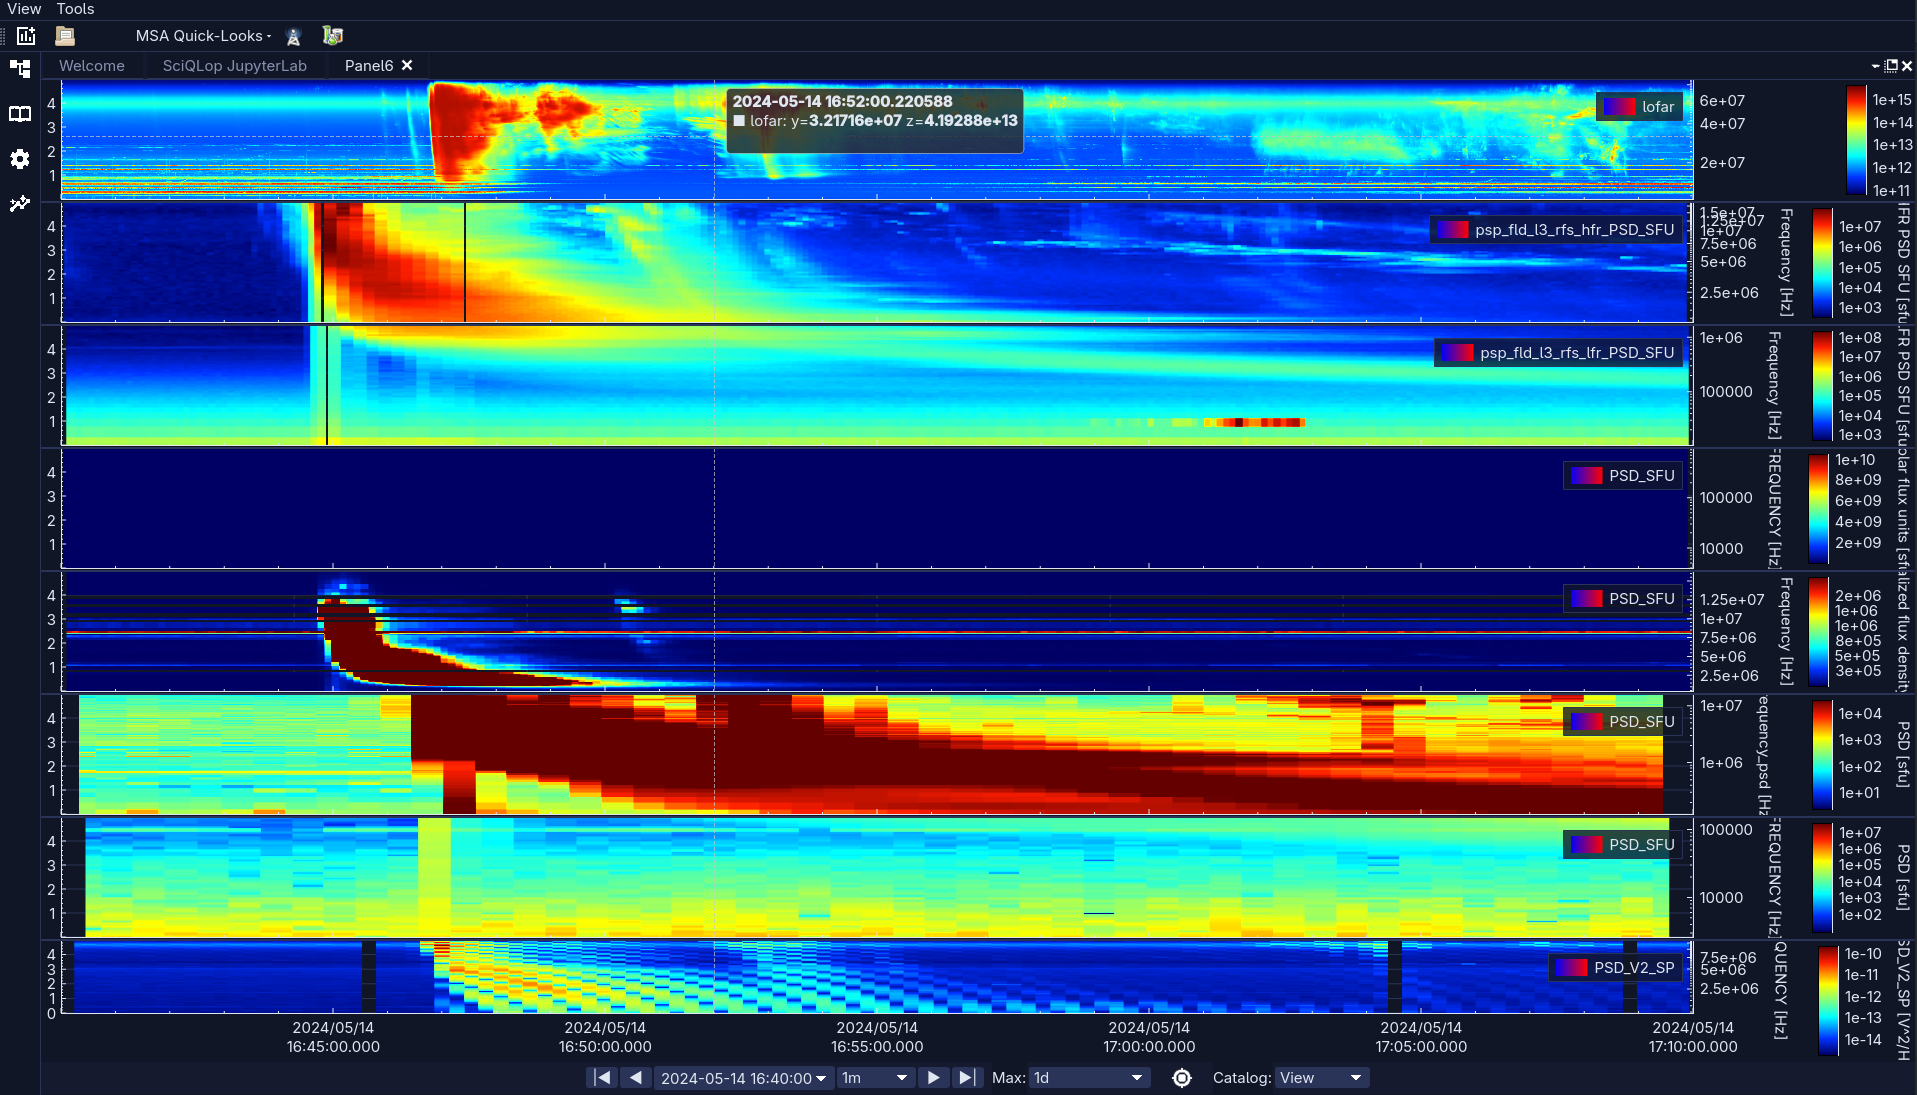